# Hotel Revenue Analysis
## Exploratory Data Analysis of Hotel Booking Performance

**Author:** Claudia Chu  
**Date:** March 2026  
**Tools:** Python, pandas, matplotlib, seaborn  
**Dataset:** [Hotel Booking Demand – Kaggle](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand)

---

## Business Context

This analysis explores booking and revenue patterns across two hotel types — a **City Hotel** and a **Resort Hotel** — covering the period 2015–2017.

As a finance professional with 9 years of experience in hotel financial control, I apply industry-standard KPIs to identify performance drivers, seasonal trends, and the financial impact of cancellations.

**Key questions this analysis answers:**
- What is the cancellation rate and its estimated revenue impact?
- What is the confirmed booking volume and total nights stayed across seasons and years?
- What is the Average Daily Rate (ADR) by hotel type and season?
- Which booking channels generate the most revenue?
- What actionable recommendations can improve financial performance?

In [18]:
# Import Libraries & Load Data

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'sans-serif'

# Load dataset
df = pd.read_csv('../data/hotel_booking.csv')

# First look
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nHotel types:\n{df['hotel'].value_counts()}")
print(f"\nYears covered: {sorted(df['arrival_date_year'].unique())}")
print(f"\nNull values per column (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Dataset shape: 119,390 rows × 36 columns

Hotel types:
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

Years covered: [np.int64(2015), np.int64(2016), np.int64(2017)]

Null values per column (top 10):
company                    112593
agent                       16340
country                       488
children                        4
arrival_date_year               0
lead_time                       0
is_canceled                     0
hotel                           0
stays_in_weekend_nights         0
stays_in_week_nights            0
dtype: int64


In [19]:
# Data Cleaning

# 1. Fill nulls
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0)

# 2. Drop 'company' column - 94% null, not useful
df.drop(columns=['company'], inplace=True)

# 3. Remove invalid stays (0 nights in both weekend and week)
invalid = df[(df['stays_in_weekend_nights'] == 0) & 
             (df['stays_in_week_nights'] == 0)]
print(f"Invalid stays (0 nights): {len(invalid):,} rows removed")
df = df[~((df['stays_in_weekend_nights'] == 0) & 
          (df['stays_in_week_nights'] == 0))]

# 4. Create useful columns
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['revenue_per_booking'] = df['adr'] * df['total_nights']

# 5. Map month numbers for sorting
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
df['arrival_date_month'] = pd.Categorical(
    df['arrival_date_month'], categories=month_order, ordered=True)

# Summary
print(f"\nClean dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"New columns added: total_nights, total_guests, revenue_per_booking")
print(f"\nADR stats (Average Daily Rate):")
print(df[df['is_canceled']==0]['adr'].describe().round(2))

Invalid stays (0 nights): 715 rows removed

Clean dataset: 118,675 rows × 38 columns
New columns added: total_nights, total_guests, revenue_per_booking

ADR stats (Average Daily Rate):
count    74486.00
mean       100.90
std         48.49
min         -6.38
25%         68.00
50%         93.20
75%        125.10
max        510.00
Name: adr, dtype: float64


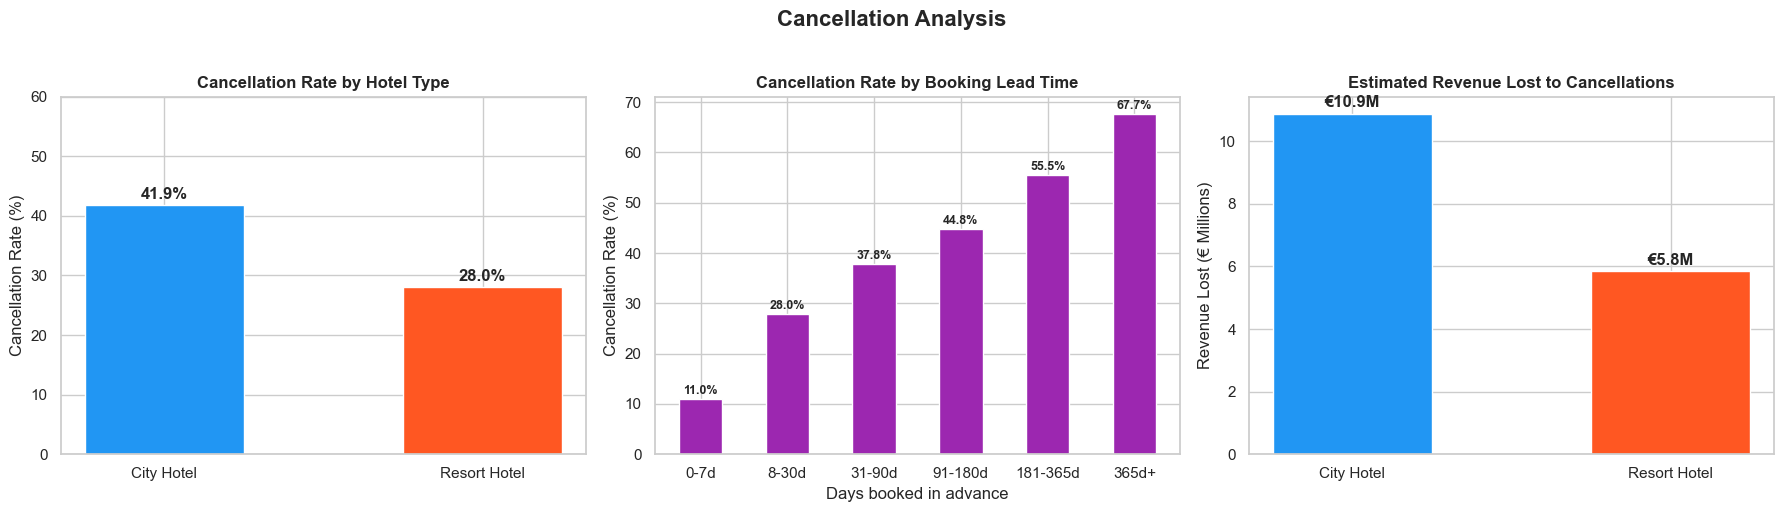

Chart saved to images/

Cancellation Summary:
Overall cancellation rate: 37.2%
City Hotel: 41.9% | Resort Hotel: 28.0%

Estimated total revenue lost to cancellations:
City Hotel:   €10.89M
Resort Hotel: €5.84M
TOTAL:        €16.73M


In [20]:
# Cancellation Analysis

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Cancellation Analysis', fontsize=16, fontweight='bold', y=1.02)

# --- Chart 1: Cancellation rate by hotel type ---
cancel_rate = df.groupby('hotel')['is_canceled'].mean() * 100

axes[0].bar(cancel_rate.index, cancel_rate.values, 
            color=['#2196F3', '#FF5722'], width=0.5)
axes[0].set_title('Cancellation Rate by Hotel Type', fontweight='bold')
axes[0].set_ylabel('Cancellation Rate (%)')
axes[0].set_ylim(0, 60)
for i, v in enumerate(cancel_rate.values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# --- Chart 2: Cancellation rate by lead time bucket ---
df['lead_time_bucket'] = pd.cut(df['lead_time'], 
    bins=[0, 7, 30, 90, 180, 365, 999],
    labels=['0-7d', '8-30d', '31-90d', '91-180d', '181-365d', '365d+'])

lead_cancel = df.groupby('lead_time_bucket', observed=True)['is_canceled'].mean() * 100

axes[1].bar(lead_cancel.index, lead_cancel.values, color='#9C27B0', width=0.5)
axes[1].set_title('Cancellation Rate by Booking Lead Time', fontweight='bold')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].set_xlabel('Days booked in advance')
for i, v in enumerate(lead_cancel.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

# --- Chart 3: Revenue lost to cancellations ---
df_canceled = df[df['is_canceled'] == 1]
df_canceled_valid = df_canceled[df_canceled['adr'] > 0]
revenue_lost = df_canceled_valid.groupby('hotel')['revenue_per_booking'].sum()

axes[2].bar(revenue_lost.index, revenue_lost.values / 1e6,
            color=['#2196F3', '#FF5722'], width=0.5)
axes[2].set_title('Estimated Revenue Lost to Cancellations', fontweight='bold')
axes[2].set_ylabel('Revenue Lost (€ Millions)')
for i, v in enumerate(revenue_lost.values / 1e6):
    axes[2].text(i, v + 0.2, f'€{v:.1f}M', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/cancellation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to images/")

# Key stats
print(f"\nCancellation Summary:")
print(f"Overall cancellation rate: {df['is_canceled'].mean()*100:.1f}%")
print(f"City Hotel: {cancel_rate['City Hotel']:.1f}% | Resort Hotel: {cancel_rate['Resort Hotel']:.1f}%")
print(f"\nEstimated total revenue lost to cancellations:")
print(f"City Hotel:   €{revenue_lost['City Hotel']/1e6:.2f}M")
print(f"Resort Hotel: €{revenue_lost['Resort Hotel']/1e6:.2f}M")
print(f"TOTAL:        €{revenue_lost.sum()/1e6:.2f}M")

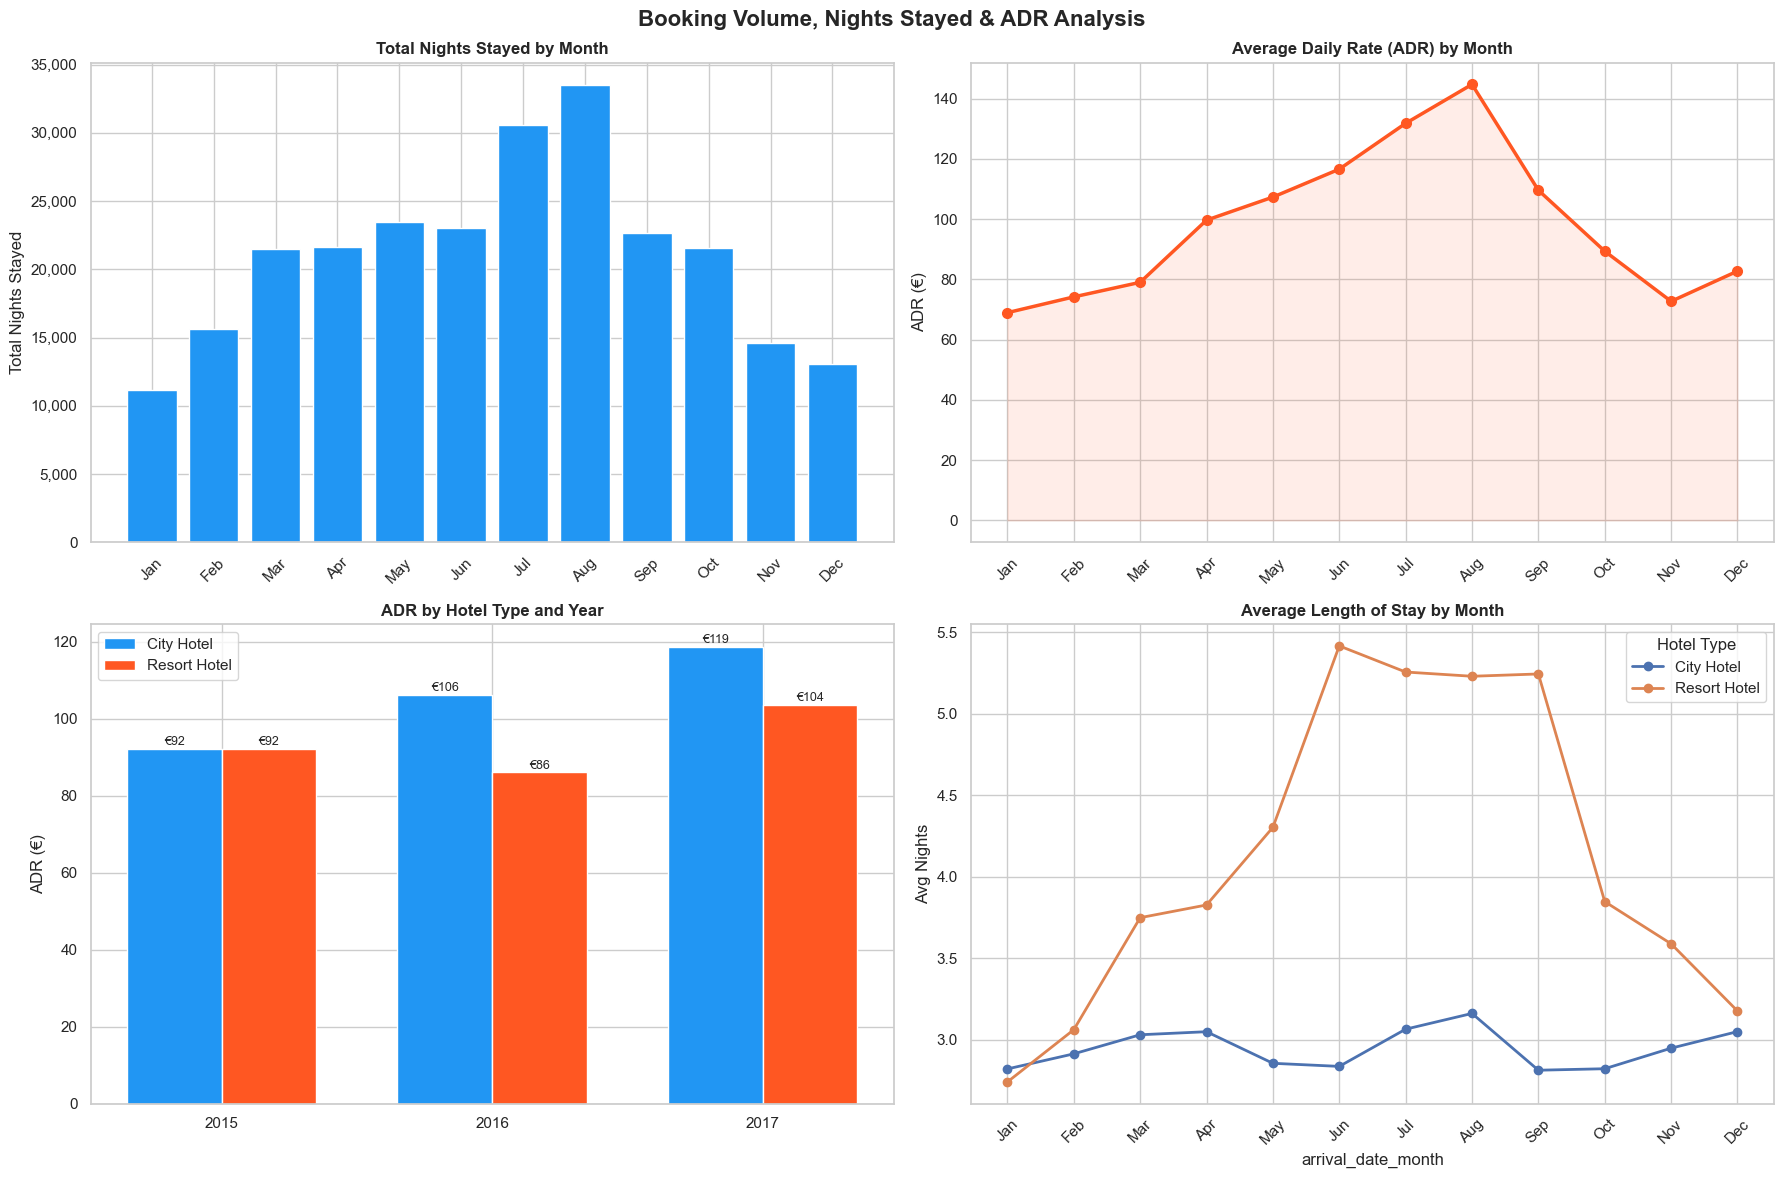

Chart saved to images/

Summary (confirmed bookings only):
Overall ADR: €102.37

ADR by hotel type:
hotel
City Hotel      108.27
Resort Hotel     92.93
Name: adr, dtype: float64

Avg length of stay by hotel type:
hotel
City Hotel      2.95
Resort Hotel    4.20
Name: total_nights, dtype: float64

Total nights stayed:
Peak month:    August (33,470 nights)
Weakest month: January (11,158 nights)

Peak ADR month: August (€144.69)


In [21]:
# Booking Volume, Nights Stayed & ADR Analysis

# Filter only confirmed bookings (not cancelled)
df_stayed = df[df['is_canceled'] == 0].copy()
df_stayed = df_stayed[df_stayed['adr'] > 0]

# Calculate total nights stayed per month
df_stayed['total_nights'] = df_stayed['stays_in_weekend_nights'] + df_stayed['stays_in_week_nights']
nights_by_month = df_stayed.groupby('arrival_date_month', observed=True)['total_nights'].sum()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Booking Volume, Nights Stayed & ADR Analysis', 
             fontsize=16, fontweight='bold')

# --- Chart 1: Total nights stayed by month ---
axes[0,0].bar(range(len(nights_by_month)), nights_by_month.values, color='#2196F3')
axes[0,0].set_xticks(range(len(nights_by_month)))
axes[0,0].set_xticklabels([m[:3] for m in nights_by_month.index], rotation=45)
axes[0,0].set_title('Total Nights Stayed by Month', fontweight='bold')
axes[0,0].set_ylabel('Total Nights Stayed')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# --- Chart 2: ADR by month ---
adr_monthly = df_stayed.groupby('arrival_date_month', observed=True)['adr'].mean()

axes[0,1].plot(range(len(adr_monthly)), adr_monthly.values, 
               color='#FF5722', marker='o', linewidth=2.5, markersize=7)
axes[0,1].set_xticks(range(len(adr_monthly)))
axes[0,1].set_xticklabels([m[:3] for m in adr_monthly.index], rotation=45)
axes[0,1].set_title('Average Daily Rate (ADR) by Month', fontweight='bold')
axes[0,1].set_ylabel('ADR (€)')
axes[0,1].fill_between(range(len(adr_monthly)), adr_monthly.values, alpha=0.1, color='#FF5722')

# --- Chart 3: ADR by hotel type and year ---
adr_hotel_year = df_stayed.groupby(['arrival_date_year', 'hotel'])['adr'].mean().unstack()

x = range(len(adr_hotel_year))
width = 0.35
axes[1,0].bar([i - width/2 for i in x], adr_hotel_year['City Hotel'], 
              width, label='City Hotel', color='#2196F3')
axes[1,0].bar([i + width/2 for i in x], adr_hotel_year['Resort Hotel'], 
              width, label='Resort Hotel', color='#FF5722')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(adr_hotel_year.index)
axes[1,0].set_title('ADR by Hotel Type and Year', fontweight='bold')
axes[1,0].set_ylabel('ADR (€)')
axes[1,0].legend()
for i, (c, r) in enumerate(zip(adr_hotel_year['City Hotel'], 
                                 adr_hotel_year['Resort Hotel'])):
    axes[1,0].text(i - width/2, c + 1, f'€{c:.0f}', ha='center', fontsize=9)
    axes[1,0].text(i + width/2, r + 1, f'€{r:.0f}', ha='center', fontsize=9)

# --- Chart 4: Average length of stay by hotel type ---
stay_month = df_stayed.groupby(['hotel', 'arrival_date_month'], 
                                observed=True)['total_nights'].mean().unstack(0)

stay_month.plot(ax=axes[1,1], marker='o', linewidth=2)
axes[1,1].set_xticks(range(12))
axes[1,1].set_xticklabels([m[:3] for m in month_order], rotation=45)
axes[1,1].set_title('Average Length of Stay by Month', fontweight='bold')
axes[1,1].set_ylabel('Avg Nights')
axes[1,1].legend(title='Hotel Type')

plt.tight_layout()
plt.savefig('../images/bookings_adr_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to images/")

# Key stats
print("\nSummary (confirmed bookings only):")
print(f"Overall ADR: €{df_stayed['adr'].mean():.2f}")
print("\nADR by hotel type:")
print(df_stayed.groupby('hotel')['adr'].mean().round(2))
print("\nAvg length of stay by hotel type:")
print(df_stayed.groupby('hotel')['total_nights'].mean().round(2))
print("\nTotal nights stayed:")
print(f"Peak month:    {nights_by_month.idxmax()} ({nights_by_month.max():,} nights)")
print(f"Weakest month: {nights_by_month.idxmin()} ({nights_by_month.min():,} nights)")
print(f"\nPeak ADR month: {adr_monthly.idxmax()} (€{adr_monthly.max():.2f})")

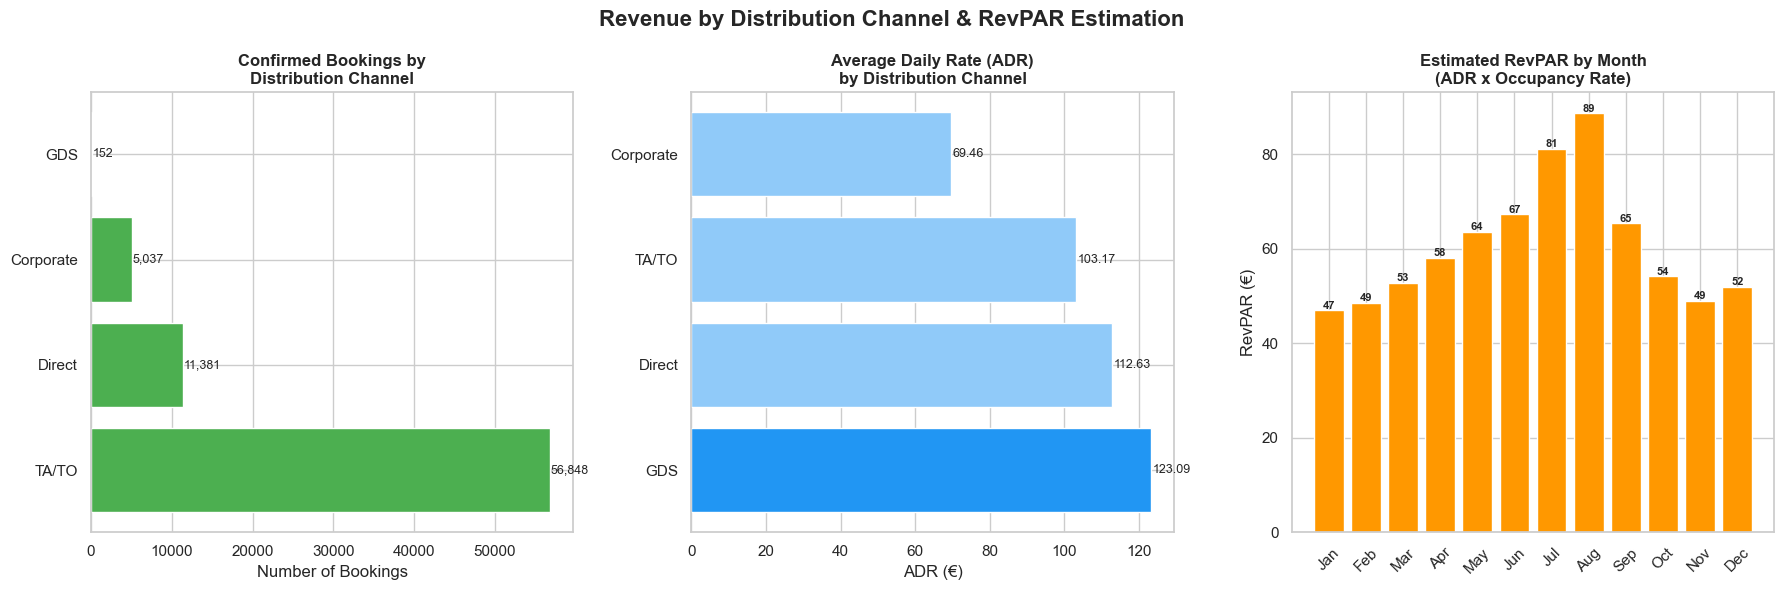

Chart saved to images/

Distribution Channel Summary:

Top channel by volume:
distribution_channel
TA/TO        56848
Direct       11381
Corporate     5037
dtype: int64

ADR by channel:
distribution_channel
GDS          123.09
Direct       112.63
TA/TO        103.17
Corporate     69.46
Name: adr, dtype: float64

Estimated RevPAR:
Peak month:    August (88.77)
Weakest month: January (47.00)
Annual avg:    60.68


In [22]:
# Distribution Channels & RevPAR Analysis

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Revenue by Distribution Channel & RevPAR Estimation', 
             fontsize=16, fontweight='bold')

# --- Chart 1: Bookings by distribution channel ---
channel = df_stayed.groupby('distribution_channel').size().sort_values(ascending=False)
channel = channel[channel.index != 'Undefined']

axes[0].barh(channel.index, channel.values, color='#4CAF50')
axes[0].set_title('Confirmed Bookings by\nDistribution Channel', fontweight='bold')
axes[0].set_xlabel('Number of Bookings')
for i, v in enumerate(channel.values):
    axes[0].text(v + 100, i, f'{v:,}', va='center', fontsize=9)

# --- Chart 2: ADR by distribution channel ---
adr_channel = df_stayed[df_stayed['distribution_channel'] != 'Undefined']\
    .groupby('distribution_channel')['adr'].mean().sort_values(ascending=False)

colors = ['#2196F3' if v == adr_channel.max() else '#90CAF9' for v in adr_channel.values]
axes[1].barh(adr_channel.index, adr_channel.values, color=colors)
axes[1].set_title('Average Daily Rate (ADR)\nby Distribution Channel', fontweight='bold')
axes[1].set_xlabel('ADR (€)')
for i, v in enumerate(adr_channel.values):
    axes[1].text(v + 0.5, i, f'{v:.2f}', va='center', fontsize=9)

# --- Chart 3: Estimated RevPAR by month ---
total_by_month = df.groupby('arrival_date_month', observed=True).size()
stayed_by_month = df_stayed.groupby('arrival_date_month', observed=True).size()
occupancy_proxy = stayed_by_month / total_by_month
adr_m = df_stayed.groupby('arrival_date_month', observed=True)['adr'].mean()
revpar = adr_m * occupancy_proxy

axes[2].bar(range(12), revpar.values, color='#FF9800')
axes[2].set_xticks(range(12))
axes[2].set_xticklabels([m[:3] for m in month_order], rotation=45)
axes[2].set_title('Estimated RevPAR by Month\n(ADR x Occupancy Rate)', fontweight='bold')
axes[2].set_ylabel('RevPAR (€)')
for i, v in enumerate(revpar.values):
    axes[2].text(i, v + 0.3, f'{v:.0f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/channels_revpar_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to images/")

# Key stats
print("\nDistribution Channel Summary:")
print("\nTop channel by volume:")
print(channel.head(3))
print("\nADR by channel:")
print(adr_channel.round(2))
print("\nEstimated RevPAR:")
peak = revpar.idxmax()
low = revpar.idxmin()
print(f"Peak month:    {peak} ({revpar.max():.2f})")
print(f"Weakest month: {low} ({revpar.min():.2f})")
print(f"Annual avg:    {revpar.mean():.2f}")

## Key Findings & Business Recommendations

---

### Finding 1: Cancellation rates are critically high
- Overall cancellation rate: **37.2%** (City Hotel: 41.9% | Resort Hotel: 28.0%)
- Industry benchmark for healthy operations: **20–25%**
- Estimated revenue lost to cancellations: **€16.73M** across both properties
- Bookings made **365+ days in advance** cancel at a 67.7% rate — largely speculative reservations

**Recommendation:** Implement a tiered deposit policy — require **25–50% non-refundable deposit** for bookings made more than 90 days in advance. Introduce dynamic cancellation penalties that increase closer to arrival date. This alone could recover an estimated **€4–6M** in protected revenue annually.

---

### Finding 2: Direct bookings are underutilised despite being the most profitable channel
- Direct bookings generate **€112.63 ADR** vs TA/TO at €103.17
- Direct channel has **zero commission cost** (typically 15–25% for OTAs)
- Yet TA/TO represents **76% of all confirmed bookings** vs Direct at only **15%**

**Recommendation:** Invest in a **Best Rate Guarantee** program and loyalty incentives for direct bookings. Even shifting 10% of TA/TO volume to Direct could generate **€1.2–1.8M** in additional net revenue through commission savings alone.

---

### Finding 3: Seasonal RevPAR gap represents a major revenue opportunity
- RevPAR peaks at **€88.77 in August** and drops to **€47.00 in January** — a 47% gap
- Low season months (Jan, Feb, Nov, Dec) show both low occupancy and low ADR simultaneously

**Recommendation:** Develop targeted **low-season packages** combining extended stays (minimum 3 nights), F&B inclusions, and corporate rates for the City Hotel. For the Resort Hotel, promote family packages in shoulder months (May, June, September) when length of stay is already high but occupancy drops.

---

### Finding 4: Resort Hotel has a strong length-of-stay advantage
- Resort Hotel average stay: **4.20 nights** vs City Hotel **2.95 nights**
- In summer months (Jun–Aug), Resort Hotel stays reach **5.4 nights**
- Longer stays reduce operational costs per guest and improve housekeeping efficiency

**Recommendation:** Introduce **minimum stay requirements** of 3–4 nights during peak season for the Resort Hotel to optimise occupancy and reduce turnover costs. Offer a discount incentive (5–10%) for stays of 5+ nights.

---

### Finding 5: ADR growth trend is positive but uneven
- City Hotel ADR grew **29%** from €92 (2015) to €119 (2017)
- Resort Hotel ADR recovered from €92 (2015) → €86 (2016) → €104 (2017)
- The 2016 dip in Resort Hotel ADR suggests a reactive pricing strategy rather than proactive revenue management

**Recommendation:** Implement a **forward-looking pricing model** using lead time and historical occupancy data to set rates dynamically. The data shows clear patterns (August peak, January trough) that can be systematically monetised through automated pricing rules.

---
*Analysis based on Hotel Booking Demand dataset (Kaggle). Revenue estimates are directional and based on dataset ADR and volume figures.*